# Calcolo degli spettri di potenza su tutti i file del dataset

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from lib.readwav import readwav
#from lib.functions import get_average_spectrum
import ipywidgets as widgets
from numpy.lib.stride_tricks import sliding_window_view
from scipy import signal 

In [2]:
%matplotlib widget
plt.close('all')

NOTA: non stiamo tagliando ne l'attacco ne la coda. Lo step potrebbe essere calcolato meglio in base alla durata del campione, ma per ora è un valore fisso.

In [3]:
# trova i file disponibili
available_files = [f for f in os.listdir('Data_organ') if f.endswith('.wav')]

available_files = sorted(available_files, key=lambda x: int(x.split("_")[1].split(".")[0]), reverse=False) # ordina i file in base al numero dopo "organ_"

available_files =  available_files

print("File disponibili:")
for f in available_files:
    print(f)

File disponibili:
note_1.wav
note_2.wav
note_3.wav
note_4.wav
note_5.wav
note_6.wav
note_7.wav
note_8.wav
note_9.wav
note_10.wav
note_11.wav
note_12.wav
note_13.wav
note_14.wav
note_15.wav
note_16.wav
note_17.wav
note_18.wav
note_19.wav
note_20.wav
note_21.wav
note_22.wav
note_23.wav
note_24.wav
note_25.wav
note_26.wav
note_27.wav
note_28.wav
note_29.wav
note_30.wav
note_31.wav
note_32.wav
note_33.wav
note_34.wav
note_35.wav
note_36.wav
note_37.wav
note_38.wav
note_39.wav
note_40.wav
note_41.wav
note_42.wav
note_43.wav
note_44.wav
note_45.wav
note_46.wav
note_47.wav
note_48.wav
note_49.wav
note_50.wav
note_51.wav
note_52.wav
note_53.wav
note_54.wav
note_55.wav
note_56.wav
note_57.wav
note_58.wav
note_59.wav
note_60.wav
note_61.wav
note_62.wav
note_63.wav
note_64.wav
note_65.wav
note_66.wav
note_67.wav
note_68.wav
note_69.wav
note_70.wav
note_71.wav
note_72.wav
note_73.wav
note_74.wav
note_75.wav
note_76.wav
note_77.wav
note_78.wav
note_79.wav
note_80.wav
note_81.wav
note_82.wav
note_83

In [4]:
# def avg_spectrum_gaussian(
#     signal, # segnale da analizzare
#     fs, # rate
#     sigma_samples, 
#     step_size,
#     span_sigma=3.0,     # quante sigma includere nella finestra. Numeri bassi riducono la risoluzione in frequenza, numeri alti aumentano il rumore
#     n_fft=None, # numero di punti per la FFT. Se None, usa window_size. Deve essere >= window_size
#     chunk_size=256
# ):
    
#     signal_float = signal.astype(np.float64)
#     power = np.convolve(signal_float**2, np.ones(1000) / 1000, mode='same')
#     rms = np.sqrt(np.maximum(power, 0))
#     threshold = np.max(rms) * 0.5 # Define a threshold at 50% of the maximum RMS to identify stable regions
#     stable_indices = np.where(rms > threshold)[0] # Get indices of samples where the RMS exceeds the threshold, indicating stable signal regions

#     if stable_indices.size == 0:

#         segment = signal
#     else:
#         start, end = stable_indices[0], stable_indices[-1] # Define the start and end indices of the stable region based on the first and last indices where the RMS exceeds the threshold
#         if end <= start:
#             segment = signal
#         else:
#             segment = signal[start:end]

#     window_size = int(np.ceil(2 * span_sigma * sigma_samples)) # dimensione della finestra in campioni
#     window_size = max(window_size, 8)

#     if window_size > len(segment):
#         raise ValueError("window_size troppo grande rispetto al segnale")

#     if window_size % 2 != 0: # assicurati che window_size sia pari per avere una finestra simmetrica
#         window_size += 1

#     if n_fft is None:
#         n_fft = window_size
#     if n_fft < window_size:
#         raise ValueError("n_fft deve essere >= window_size")

#     # finestre scorrevoli
#     frames = sliding_window_view(segment, window_size)[::step_size] # prendi solo le finestre a step_size campioni di distanza
#     n_windows = frames.shape[0] # numero di finestre ottenute
#     if n_windows == 0:
#         raise ValueError("Nessuna finestra: riduci window_size o step_size")

#     # gaussiana centrata con sigma scelto
#     n = np.arange(window_size) # crea l'asse delle ascisse
#     c = (window_size - 1) / 2.0 # centro della finestra
#     g = np.exp(-0.5 * ((n - c) / sigma_samples) ** 2) # calcola la gaussiana

#     # normalizzazione
#     g /= np.sqrt(np.sum(g**2))

#     # accumulo a blocchi
#     acc = np.zeros(n_fft // 2 + 1, dtype=np.float64)  # accumulatore per lo spettro medio, dimensione n_fft//2+1 per la FFT reale (rfft)

#     for i in range(0, n_windows, chunk_size): # processa a blocchi di chunk_size finestre
#         chunk = frames[i:i + chunk_size] * g
#         spec = np.abs(np.fft.rfft(chunk, n=n_fft, axis=-1)) ** 2
#         acc += spec.sum(axis=0)

#     avg_spectrum = acc / n_windows
#     freqs = np.fft.rfftfreq(n_fft, d=1/fs)
#     return freqs, avg_spectrum

# def avg_spectrum_gaussian(
#     signal,             # segnale da analizzare
#     fs,                 # rate
#     sigma_samples, 
#     step_size,
#     span_sigma=3.0,     # quante sigma includere nella finestra. 
#     n_fft=None,         # numero di punti per la FFT. Se None, usa window_size. Deve essere >= window_size
#     chunk_size=256
# ):
    
#     signal_float = signal.astype(np.float64)
    
#     # 1. Calcolo RMS robusto (finestra di 50ms basata su fs, non fissa a 1000)
#     rms_win_len = max(int(0.05 * fs), 1) 
#     power = np.convolve(signal_float**2, np.ones(rms_win_len) / rms_win_len, mode='same')
#     rms = np.sqrt(np.maximum(power, 0))
    
#     # 2. Soglia robusta immune ai click isolati (95° percentile)
#     robust_max = np.percentile(rms, 95)
#     threshold = robust_max * 0.5 # Define a threshold at 50% of the max stable RMS
#     stable_indices = np.where(rms > threshold)[0]

#     # 3. Estrazione del segmento stabile
#     if stable_indices.size == 0:
#         segment = signal
#     else:
#         start, end = stable_indices[0], stable_indices[-1] 
#         if end <= start:
#             segment = signal
#         else:
#             segment = signal[start:end]

#     # 4. Calcolo della reale dimensione della finestra in campioni
#     window_size = int(np.ceil(2 * span_sigma * sigma_samples)) 
#     window_size = max(window_size, 8)

#     if window_size > len(segment):
#         raise ValueError("window_size troppo grande rispetto al segnale")

#     if window_size % 2 != 0: # assicurati che window_size sia pari per avere una finestra simmetrica
#         window_size += 1

#     if n_fft is None:
#         n_fft = window_size
#     if n_fft < window_size:
#         raise ValueError("n_fft deve essere >= window_size")

#     # 5. Finestre scorrevoli
#     frames = sliding_window_view(segment, window_size)[::step_size] 
#     n_windows = frames.shape[0] 
#     if n_windows == 0:
#         raise ValueError("Nessuna finestra: riduci window_size o step_size")

#     # 6. Gaussiana centrata con sigma scelto
#     n = np.arange(window_size) 
#     c = (window_size - 1) / 2.0 
#     g = np.exp(-0.5 * ((n - c) / sigma_samples) ** 2) 

#     # Normalizzazione per conservare l'energia della finestra
#     g /= np.sqrt(np.sum(g**2))

#     # 7. Accumulo a blocchi
#     acc = np.zeros(n_fft // 2 + 1, dtype=np.float64)  

#     for i in range(0, n_windows, chunk_size): 
#         chunk = frames[i:i + chunk_size] * g
#         spec = np.abs(np.fft.rfft(chunk, n=n_fft, axis=-1)) ** 2
#         acc += spec.sum(axis=0)

#     avg_spectrum = acc / n_windows
#     freqs = np.fft.rfftfreq(n_fft, d=1/fs)
    
#     return freqs, avg_spectrum

In [5]:
# num_periods = 24    # numero di periodi da includere nella singola finestra

# avg_spectra = {}

# for i, filename in enumerate(available_files):

#     print(f"Processing file {i+1}/{len(available_files)}: {filename}")

#     # carica il file e seleziona il canale
#     rate, data = readwav(os.path.join('Data_organ', filename))
#     channel1 = data[:,0]

#     N = len(channel1)

#     # stima periodo e calcolo della finestra gaussiana
#     signal_peaks, _ = sp.signal.find_peaks(channel1[N//2-5000:N//2+5000], height=np.max(channel1)*0.1)
#     differences = np.diff(signal_peaks)
#     period = np.mean(differences) / rate
#     window_size = int(num_periods * period * rate)

#     step_size = window_size // 4
#     span_sigma_val = 5
#     sigma_samples = window_size / (2 * span_sigma_val)

#     try:
#         # calcola spettro di potenza medio facendo scorrere la finestra gaussiana lungo il segnale
#         #freqs, avg_spectrum = avg_spectrum_gaussian(channel1, rate, window_size, step_size=step_size, span_sigma=5)
#         #freqs, avg_spectrum = avg_spectrum_gaussian(channel1, rate, sigma_samples, step_size=step_size, span_sigma=span_sigma_val)
#         #freqs, avg_spectrum = get_average_spectrum(channel1, rate, window_size, step_size)
#         freqs, avg_spectrum = signal.welch(
#         channel1,                  # Il tuo segnale audio
#         fs=rate,                   # Frequenza di campionamento
#         window='hann',             # Tipo di finestra (Hanning è lo standard per l'audio)
#         nperseg=len(window_size),       # Dimensione della singola finestra
#         noverlap=window_size // 4, # Sovrapposizione (overlap), es. 75%
#         nfft=131072,               # Numero di punti per la FFT (Zero-padding)
#         scaling='spectrum'         # Restituisce l'ampiezza (Volt^2) anziché la densità
#     )
        
#         avg_spectra[filename] = (freqs, avg_spectrum)

        
#     except ValueError as e:
#         print(f"Errore nel file {filename}: {e}")
#         continue


In [ ]:
from scipy.fft import rfft, rfftfreq
avg_spectra = {}

for i, filename in enumerate(available_files):

    print(f"Processing file {i+1}/{len(available_files)}: {filename}")

    rate, data = readwav(os.path.join('Data_organ', filename))
    note = data[:,0]
    
    spect_r = rfft(note) 

    # Questa riga era corretta, ma ora usa la funzione importata sopra
    freq_r = rfftfreq(len(note), d=1/rate)
    
    time = np.linspace(0, note.shape[0], note.shape[0], endpoint = False) / rate
    first_15 = time[0] + 0.15 * (time[-1] - time[0])
    last_15 = time[0] + 0.85 * (time[-1] - time[0])
    cut = (time >= first_15) & (time <= last_15)
    time = time[cut]
    note = note[cut]
    

    width = (time[-1] - time[0]) / 10
    gaussian_window = sp.signal.windows.gaussian(int(width * rate), std = 0.2 * rate)
    
    freqs, avg_spectrum = sp.signal.welch(note, fs = rate, window = gaussian_window, nperseg = len(gaussian_window))

    avg_spectra[filename] = (freqs, avg_spectrum)



Processing file 1/280: note_1.wav
Processing file 2/280: note_2.wav
Processing file 3/280: note_3.wav
Processing file 4/280: note_4.wav
Processing file 5/280: note_5.wav
Processing file 6/280: note_6.wav
Processing file 7/280: note_7.wav
Processing file 8/280: note_8.wav
Processing file 9/280: note_9.wav
Processing file 10/280: note_10.wav
Processing file 11/280: note_11.wav
Processing file 12/280: note_12.wav
Processing file 13/280: note_13.wav
Processing file 14/280: note_14.wav
Processing file 15/280: note_15.wav
Processing file 16/280: note_16.wav
Processing file 17/280: note_17.wav
Processing file 18/280: note_18.wav
Processing file 19/280: note_19.wav
Processing file 20/280: note_20.wav
Processing file 21/280: note_21.wav
Processing file 22/280: note_22.wav
Processing file 23/280: note_23.wav
Processing file 24/280: note_24.wav
Processing file 25/280: note_25.wav
Processing file 26/280: note_26.wav
Processing file 27/280: note_27.wav
Processing file 28/280: note_28.wav
Processing

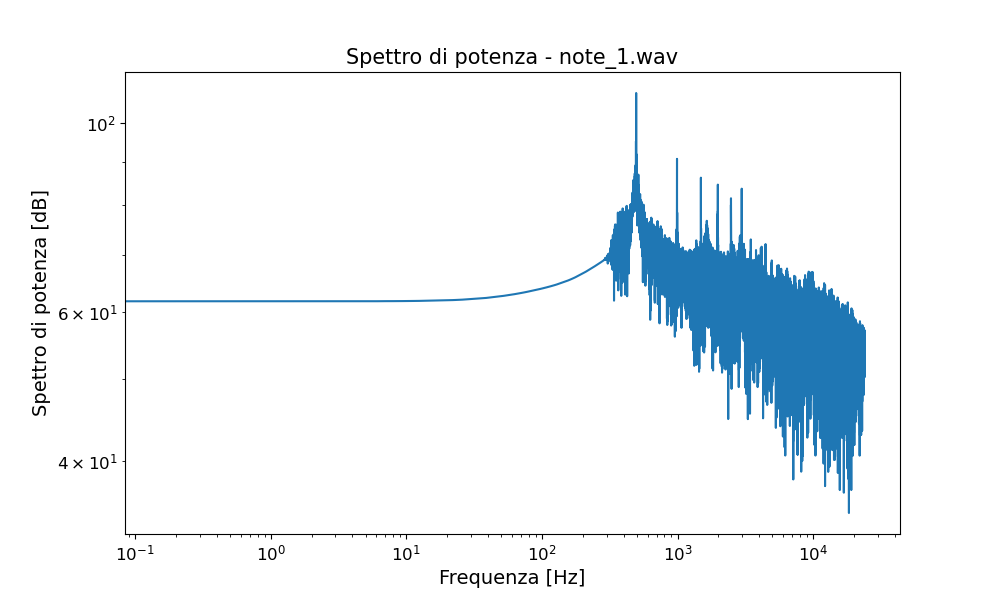

In [7]:
plt.rcParams.update({
    'font.size': 12,          # Dimensione base per tutto
    'axes.titlesize': 15,     # Titolo del grafico
    'axes.labelsize': 14,     # Etichette X e Y
    'xtick.labelsize': 12,    # Numeretti asse X
    'ytick.labelsize': 12,    # Numeretti asse Y
    'legend.fontsize': 12
})

# plot degli spettri spectra per il file 0
plt.figure(figsize=(10, 6))
plt.plot(freq_r, 10*np.log10(np.abs(spect_r)))
plt.title(f"Spettro di potenza - {available_files[0]}")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Frequenza [Hz]")
plt.ylabel("Spettro di potenza [dB]")    
plt.savefig("spettro_potenza.png", dpi=300)

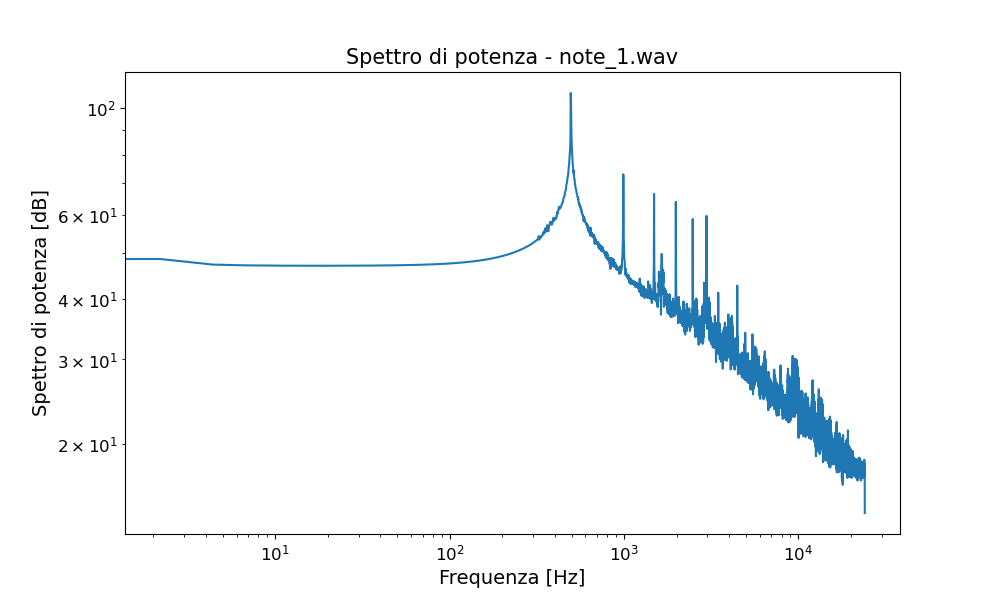

In [8]:
# plot degli spettri spectra per il file 0
plt.figure(figsize=(10, 6))
plt.plot(freqs, 10*np.log10(avg_spectrum))
plt.title(f"Spettro di potenza - {available_files[0]}")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Frequenza [Hz]")
plt.ylabel("Spettro di potenza [dB]")    

plt.savefig("spettro_potenza_medio.png", dpi=300)

Dropdown(description='Spettro:', options=('note_1.wav', 'note_2.wav', 'note_3.wav', 'note_4.wav', 'note_5.wav'…

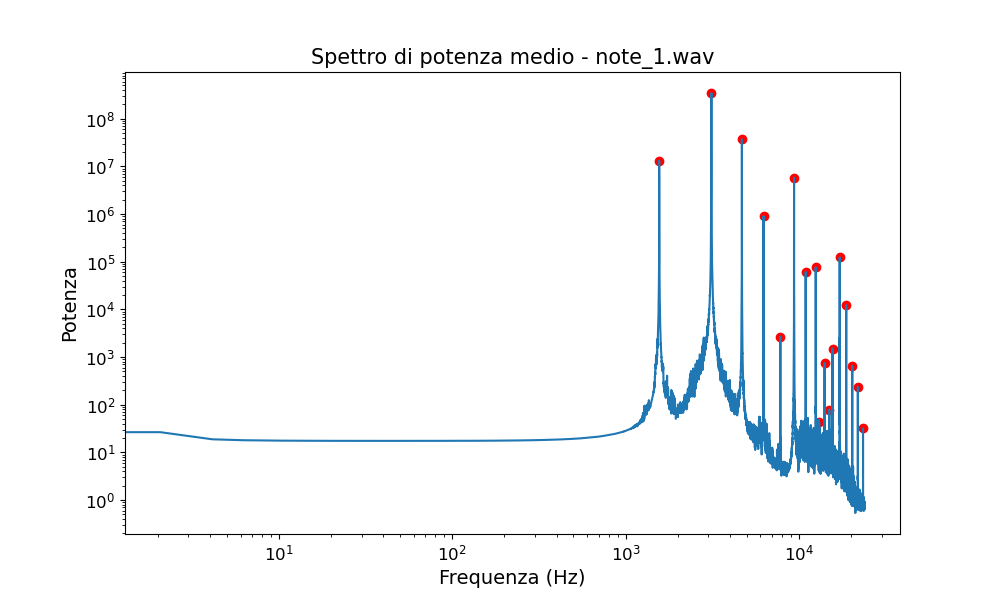

In [11]:
spectrum_selector = widgets.Dropdown( # widget per selezionare quale spettro visualizzare
    options=list(avg_spectra.keys()),
    description='Spettro:',
    disabled=False,
)

fig, ax = plt.subplots()
fig.set_size_inches(10, 6)
canvas = fig.canvas

def update_plot(change):
    filename = change['new']
    freqs, avg_spectrum = avg_spectra[filename]

    peaks,_ = sp.signal.find_peaks(np.log10(avg_spectrum), prominence=1)

    ax.clear()
    ax.plot(freqs, avg_spectrum)

    plt.scatter(freqs[peaks], avg_spectrum[peaks], color='red', label='Picchi')

    ax.set_title(f"Spettro di potenza medio - {filename}")
    ax.set_xlabel("Frequenza (Hz)")
    ax.set_ylabel("Potenza")
    ax.set_xscale('log')
    ax.set_yscale('log')

spectrum_selector.observe(update_plot, names='value')
display(spectrum_selector)
update_plot({'new': spectrum_selector.value})

In [10]:
# Salva i risultati in dati_processati/spettri_{num_periods_in_window}_periodi/{filename}_spectrum.npz
output_dir = f"dati_processati/spettri"
os.makedirs(output_dir, exist_ok=True)
for filename, (freqs, avg_spectrum) in avg_spectra.items():
    np.savez(os.path.join(output_dir, f"{filename}_spectrum.npz"), freqs=freqs, avg_spectrum=avg_spectrum)